<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch04_outlier_detection_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: The Outlier Detection Process

*Outlier Detection in Python* -- Brett Kennedy (Manning, 2024)

---

This chapter shifts from individual algorithms to the **end-to-end process** of running an outlier detection project. We walk through every step -- from determining what types of outliers matter, through data collection, cleaning, feature engineering, model fitting, evaluation, and ongoing production monitoring.

Many of these steps mirror standard machine learning workflows, but outlier detection introduces unique challenges: there are no labels to guide evaluation, feature selection is more critical (detectors treat all features equally), and the definition of "interesting" is subjective and context-dependent.

We use a **baseball career statistics** dataset as our running example, walking through the full pipeline from raw data to evaluated results.

**Key concepts in this chapter:**
- Statistical outliers vs. specific outliers vs. unknown outliers
- Rules, classifiers, and detectors as complementary tools
- Data collection, EDA, cleaning, feature engineering, encoding, and scaling
- Fitting multiple models and comparing their results
- The challenge of evaluation without ground truth
- Setting up ongoing monitoring systems

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree, KernelDensity
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.cluster import DBSCAN
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print("Environment ready.")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")

Environment ready.
NumPy: 2.0.2
pandas: 2.2.2


We use the same core stack as previous chapters. `RobustScaler` is introduced here as the preferred scaling method for outlier detection because it uses median and IQR rather than mean and standard deviation, making it resistant to the very outliers we are trying to detect.

## 4.1 Outlier Detection Workflow

The general steps for a typical outlier detection project are:

1. **Determine the types of outliers** we wish to identify
2. **Choose the model type(s)**: rules, classifiers, detectors, or a combination
3. **Collect the data** -- representative of the true population
4. **Examine the data** (EDA) -- understand distributions, correlations, and data types
5. **Clean the data** -- remove obvious outliers that would distort the model
6. **Feature selection** -- remove irrelevant features (more critical than in prediction)
7. **Feature engineering** -- create features that expose anomalies
8. **Encode / scale** -- categorical encoding and numeric scaling
9. **Fit one or more models** -- try multiple detectors with varied parameters
10. **Evaluate** -- inspect results manually, compare detectors, spot-check
11. **Combine models** into an ensemble or select the best
12. **Set up production monitoring** (if ongoing)

The process is highly **iterative**: we loop between model fitting, evaluation, and parameter tuning until results are useful. Let's walk through each step with a concrete dataset.

## 4.2 Determining the Types of Outliers

Before touching data, we must answer: **what are we looking for?** The answer shapes every subsequent decision.

### Statistical Outliers vs. Specific Outliers

**Statistical outliers** are anything statistically unusual in the data, without a preconceived target. We search broadly for records that stand out. This is the default mode for exploratory outlier detection -- the approach we focus on in this book.

**Specific outliers** are well-defined targets: data entry errors, fraud patterns, equipment failures. These are unusual not relative to the dataset but relative to an *ideal* -- what the data *should* look like. Specific outliers may not even be statistically rare (e.g., data entry errors may be quite common).

### Known vs. Unknown Outliers

**Known outliers** are types we can anticipate: extreme values, expected failure modes, seasonal anomalies. **Unknown outliers** are types we haven't even conceived of -- the unanticipated phenomena that are often the most interesting discoveries.

### Choosing Your Approach

| Looking for... | Best tool | Why |
|---|---|---|
| Statistical outliers (anything unusual) | **Outlier detectors** | Designed exactly for this; no predefined targets needed |
| Specific, well-defined patterns | **Rules** | Fast, interpretable, auditable; catch known patterns reliably |
| Specific patterns with labeled examples | **Classifiers** | Learn complex boundaries from data; produce probabilities |
| Unknown outliers | **Detectors** | Only tool that can find what you haven't anticipated |
| Comprehensive coverage | **All three combined** | Rules catch known issues; classifiers catch learned patterns; detectors catch everything else |

## 4.3 Choosing the Model Type

### 4.3.1 Rules-Based Approaches

Rules are simple scripts that check each row against predefined conditions. They have significant advantages: they are **fast**, **deterministic**, **interpretable**, and **auditable** (critical in regulated environments). Their limitation is they only catch what is specifically coded -- they will miss anything not anticipated.

### 4.3.2 Classifier-Based Approaches

Where labeled examples of the target anomaly exist, a supervised classifier (Random Forest, gradient boosting, neural network) can learn to distinguish normal from abnormal. Classifiers are more flexible than rules and produce probability scores, but they require labeled data -- which is usually scarce in outlier detection settings.

### 4.3.3 Detector-Based Approaches

Outlier detectors are unsupervised -- they learn "normal" from the data and flag anything that deviates. This is the only approach that can find *unknown* outliers. The tradeoff: detectors will also flag many irrelevant records (false positives), since "statistically unusual" does not always mean "interesting."

**In practice, the strongest systems combine all three.** Rules catch known issues reliably. Classifiers catch complex learned patterns. Detectors catch everything else. Let's demonstrate with a simple rules example.

In [2]:
# Demonstrate a rules-based approach on synthetic expense data
np.random.seed(42)
n = 500

# Generate normal expenses
staff_ids = np.random.choice([9000483, 9303332, 9847421, 9100200, 9555777], n)
accounts = np.random.choice(['Meals', 'Travel', 'Supplies', 'Payroll'], n, p=[0.35, 0.25, 0.25, 0.15])
hours = np.random.choice(range(7, 20), n)
amounts = np.abs(np.random.lognormal(3.5, 0.8, n))

# Inject anomalies
amounts[-5:] = [6500, 8200, 0.01, 0.02, 15000]   # extreme amounts
hours[-5:] = [2, 23, 3, 1, 22]                     # off-hours
accounts[-3:] = ['Unknown', 'Meals', 'Unknown']    # invalid accounts

expenses = pd.DataFrame({
    'Staff_ID': staff_ids, 'Account': accounts,
    'Hour': hours, 'Amount': np.round(amounts, 2)
})

# Rules-based outlier detection
def apply_rules(row):
    score = 0
    reasons = []
    # Rule 1: Invalid account
    valid_accounts = {'Meals', 'Travel', 'Supplies', 'Payroll', 'Inventory', 'Rent'}
    if row['Account'] not in valid_accounts:
        return 10, ['Invalid account']  # immediate flag
    # Rule 2: Off-hours
    if row['Hour'] < 7 or row['Hour'] > 20:
        return 10, ['Outside business hours']  # immediate flag
    # Rule 3: Large amount
    if row['Amount'] > 5000:
        score += 5
        reasons.append(f'Large amount: ${row["Amount"]:,.2f}')
    elif row['Amount'] > 1000:
        score += 2
        reasons.append(f'Elevated amount: ${row["Amount"]:,.2f}')
    # Rule 4: Meals threshold
    if row['Account'] == 'Meals' and row['Amount'] > 100:
        score += 4
        reasons.append(f'Meals > $100')
    # Rule 5: Suspiciously small
    if row['Amount'] < 0.10:
        score += 5
        reasons.append(f'Micro-transaction: ${row["Amount"]:,.2f}')
    return score, reasons

scores_rules = []
for _, row in expenses.iterrows():
    s, r = apply_rules(row)
    scores_rules.append({'score': s, 'reasons': r})

expenses['Rule_Score'] = [s['score'] for s in scores_rules]
expenses['Rule_Reasons'] = ['; '.join(s['reasons']) if s['reasons'] else '' for s in scores_rules]

flagged = expenses[expenses['Rule_Score'] >= 5].sort_values('Rule_Score', ascending=False)
print(f"Rules-based detection on {len(expenses)} expense records:")
print(f"  Flagged: {len(flagged)} records (score >= 5)")
print()
print("Flagged records:")
print(flagged[['Staff_ID', 'Account', 'Hour', 'Amount', 'Rule_Score', 'Rule_Reasons']].to_string(index=False))

Rules-based detection on 500 expense records:
  Flagged: 5 records (score >= 5)

Flagged records:
 Staff_ID Account  Hour   Amount  Rule_Score           Rule_Reasons
  9000483 Payroll     2  6500.00          10 Outside business hours
  9847421   Meals    23  8200.00          10 Outside business hours
  9000483 Unknown     3     0.01          10        Invalid account
  9000483   Meals     1     0.02          10 Outside business hours
  9000483 Unknown    22 15000.00          10        Invalid account


The rules-based approach catches all the injected anomalies and provides **clear, actionable reasons** for each flag. An analyst receiving this output knows exactly why each record was flagged and can act accordingly.

Notice the advantages: the rules are fast (pure Python conditionals), deterministic, and produce interpretable scores with explanations. The disadvantages are equally clear: these rules would miss any *unanticipated* anomaly -- an unusual combination of staff ID and account, a pattern of many small transactions over time, or a correlation violation between fields.

This is where **detectors complement rules**: rules catch the anticipated, detectors catch the unanticipated. The remainder of this chapter focuses on the detector-based workflow.

## 4.4 Collecting and Examining the Data

For the remainder of this chapter, we use a **baseball career statistics** dataset as our running example. This dataset has $1{,}340$ rows (players) and $16$ columns (career statistics), and we wish to find the most unusual players -- not targeting anything specific, just looking for statistical outliers.

We simulate a dataset matching the book's description since OpenML is not available in this environment. The Colab appendix includes the exact `fetch_openml` code.

In [3]:
# Create a baseball-like dataset matching the book's description
np.random.seed(42)
n_players = 1340

# Simulate realistic baseball career statistics
number_seasons = np.random.poisson(8, n_players) + 1
games_played = (number_seasons * np.random.normal(120, 40, n_players)).clip(50, 3600).astype(int)
at_bats = (games_played * np.random.normal(3.2, 0.8, n_players)).clip(100, 13000).astype(int)
batting_avg = np.random.beta(8, 22, n_players)  # centered ~0.267
hits = (at_bats * batting_avg).astype(int)
runs = (hits * np.random.normal(0.55, 0.12, n_players)).clip(0).astype(int)
doubles = (hits * np.random.beta(3, 12, n_players)).astype(int)
triples = (hits * np.random.beta(1.5, 40, n_players)).astype(int)
home_runs = (hits * np.random.beta(2, 15, n_players)).astype(int)
rbis = (runs * np.random.normal(0.9, 0.2, n_players)).clip(0).astype(int)
walks = (at_bats * np.random.beta(3, 25, n_players)).astype(int)
strikeouts_base = (at_bats * np.random.beta(4, 15, n_players)).astype(int)
# Inject 20 nulls in Strikeouts
strikeouts = strikeouts_base.astype(float)
null_idx = np.random.choice(n_players, 20, replace=False)
strikeouts[null_idx] = np.nan
on_base_pct = batting_avg + np.random.normal(0.06, 0.02, n_players)
slugging_pct = batting_avg + np.random.normal(0.12, 0.05, n_players)
fielding_avg = np.random.beta(30, 1.5, n_players)
positions = np.random.choice(
    ['Catcher', 'First_Base', 'Second_Base', 'Third_Base', 'Shortstop', 'Outfield', 'Designated_Hitter'],
    n_players, p=[0.12, 0.14, 0.14, 0.13, 0.13, 0.30, 0.04])

df = pd.DataFrame({
    'Number_seasons': number_seasons, 'Games_played': games_played,
    'At_bats': at_bats, 'Runs': runs, 'Hits': hits,
    'Doubles': doubles, 'Triples': triples, 'Home_runs': home_runs,
    'RBIs': rbis, 'Walks': walks, 'Strikeouts': strikeouts,
    'Batting_average': np.round(batting_avg, 3),
    'On_base_pct': np.round(on_base_pct, 3),
    'Slugging_pct': np.round(slugging_pct, 3),
    'Fielding_ave': np.round(fielding_avg, 3),
    'Position': positions
})

print(f"Dataset shape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes.value_counts().to_string())
print(f"\nNull values:")
print(df.isna().sum()[df.isna().sum() > 0].to_string())
print(f"\nFirst 5 rows:")
print(df.head().to_string())

Dataset shape: (1340, 16)

Column types:
int64      10
float64     5
object      1

Null values:
Strikeouts    20

First 5 rows:
   Number_seasons  Games_played  At_bats  Runs  Hits  Doubles  Triples  Home_runs  RBIs  Walks  Strikeouts  Batting_average  On_base_pct  Slugging_pct  Fielding_ave     Position
0               7           996     1395   185   382       60       45         21    93     71       261.0            0.274        0.315         0.389         0.984   First_Base
1               8           830     1908   419   739      159       16         55   310    326       472.0            0.388        0.460         0.456         0.965   First_Base
2               7           497     1359   121   249       43        7         16   140    174       225.0            0.184        0.217         0.268         0.995  Second_Base
3               8           674     2154   265   452       14        1         92   246    187       741.0            0.210        0.283         0.273         

The dataset has $1{,}340$ rows and $16$ columns: $15$ numeric features and $1$ categorical feature (`Position`). There are $20$ null values in `Strikeouts`, which we will need to handle before fitting any detector.

### Exploratory Data Analysis

As with any ML project, we start with EDA to understand distributions, spot obvious issues, and develop intuition about the data.

Figure 4.2: Distributions of Games_played, Triples, and Batting_average.
  Games_played: min=50, max=3097
  Triples: min=0, max=267
  Batting_average: min=0.088, max=0.532


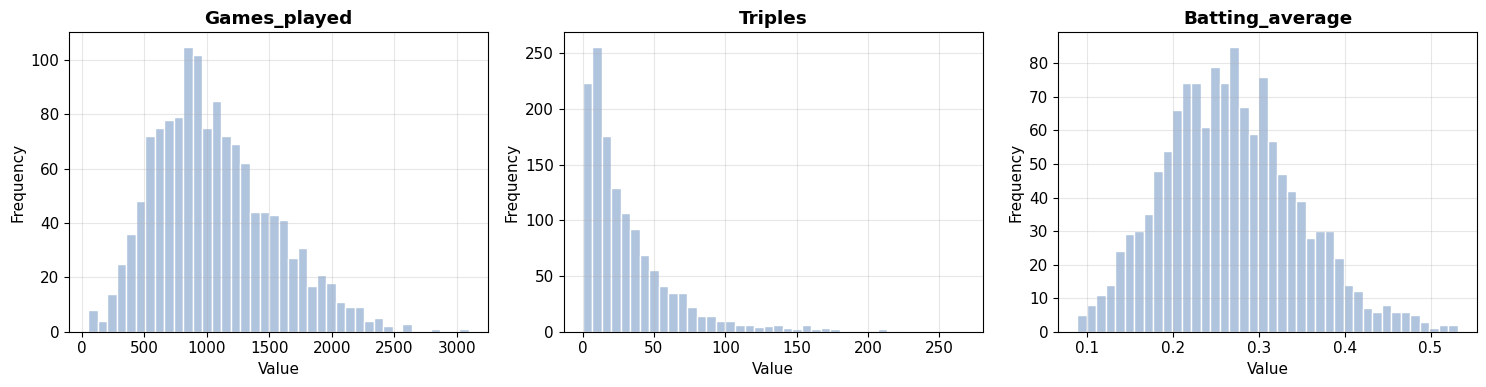

In [4]:
# Figure 4.2: Histograms of selected numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Games_played', 'Triples', 'Batting_average']):
    ax.hist(df[col].dropna(), bins=40, color='lightsteelblue', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
print("Figure 4.2: Distributions of Games_played, Triples, and Batting_average.")
print(f"  Games_played: min={df['Games_played'].min()}, max={df['Games_played'].max()}")
print(f"  Triples: min={df['Triples'].min()}, max={df['Triples'].max()}")
print(f"  Batting_average: min={df['Batting_average'].min():.3f}, max={df['Batting_average'].max():.3f}")

Each feature shows a reasonable distribution. `Games_played` is right-skewed (many players with short careers, few with long ones). `Triples` has a strong right skew with some potential extreme values. `Batting_average` is roughly bell-shaped, centered around $0.27$. None show obvious internal outliers -- only potential extreme values at the tails.

Figure 4.3: Position distribution.
  Outfield: 415 (31.0%)
  Second_Base: 188 (14.0%)
  Shortstop: 185 (13.8%)
  First_Base: 173 (12.9%)
  Catcher: 173 (12.9%)
  Third_Base: 164 (12.2%)
  Designated_Hitter: 42 (3.1%)


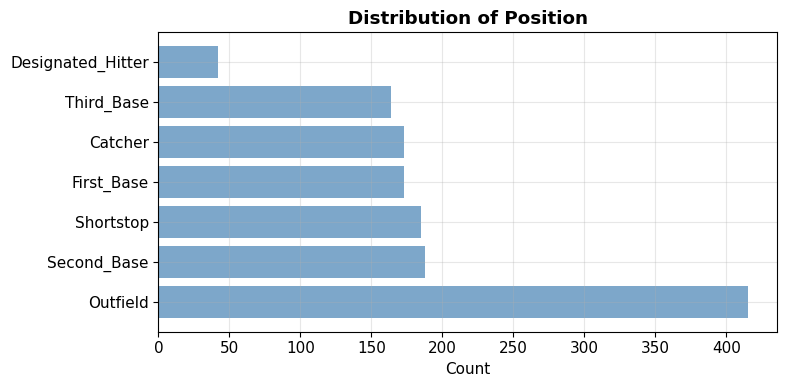

In [5]:
# Figure 4.3: Distribution of the categorical Position feature
fig, ax = plt.subplots(figsize=(8, 4))
pos_counts = df['Position'].value_counts()
ax.barh(pos_counts.index, pos_counts.values, color='steelblue', alpha=0.7)
ax.set_xlabel('Count')
ax.set_title('Distribution of Position', fontweight='bold')
plt.tight_layout()

print("Figure 4.3: Position distribution.")
for pos, count in pos_counts.items():
    print(f"  {pos}: {count} ({count/len(df)*100:.1f}%)")

The `Designated_Hitter` category is notably rare (about $4\%$ of players), but not rare enough to be considered anomalous on its own. The other positions are reasonably well-represented.

Figure 4.4: Pairwise scatterplots showing correlations between features.


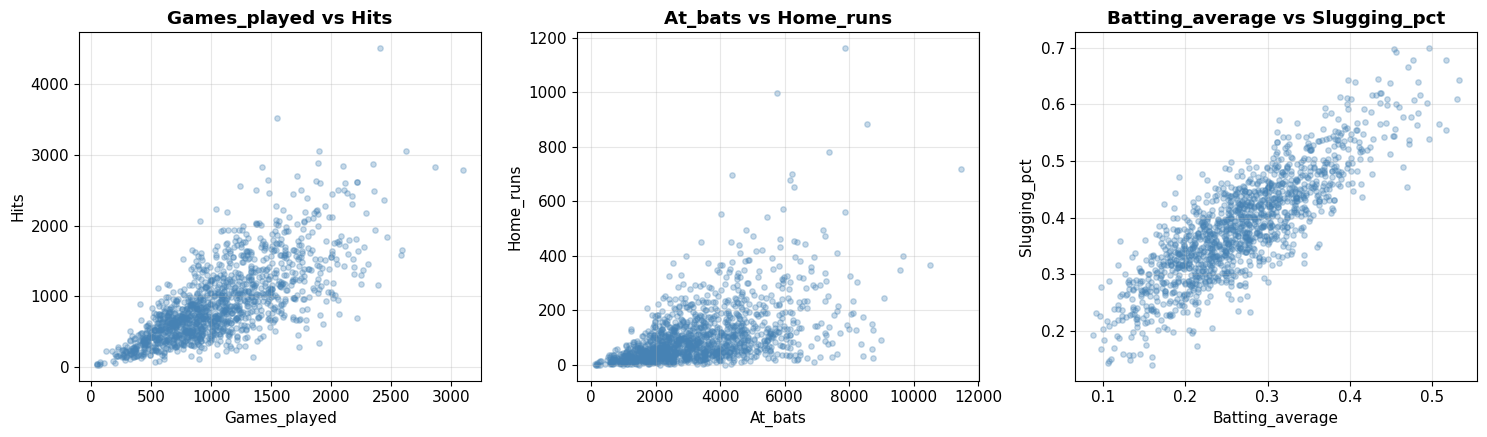

In [6]:
# Figure 4.4: Pairwise scatterplots for selected features
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pairs = [('Games_played', 'Hits'), ('At_bats', 'Home_runs'), ('Batting_average', 'Slugging_pct')]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.3, s=15, c='steelblue')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}', fontweight='bold')

plt.tight_layout()
print("Figure 4.4: Pairwise scatterplots showing correlations between features.")

The scatterplots reveal strong **correlations** between features -- which is expected, since career counting stats (games, at-bats, hits, runs, home runs) all scale with career length. This is important for two reasons:

1. **Correlated features** partially mitigate the curse of dimensionality (Chapter 3) because the data lives on a lower-dimensional manifold
2. **Ratios** (like home runs per at-bat) may reveal outliers that raw counts do not -- this motivates our feature engineering step later

Figure 4.6: Feature distributions conditioned on Position.
  Catchers show somewhat distinct patterns in some features.


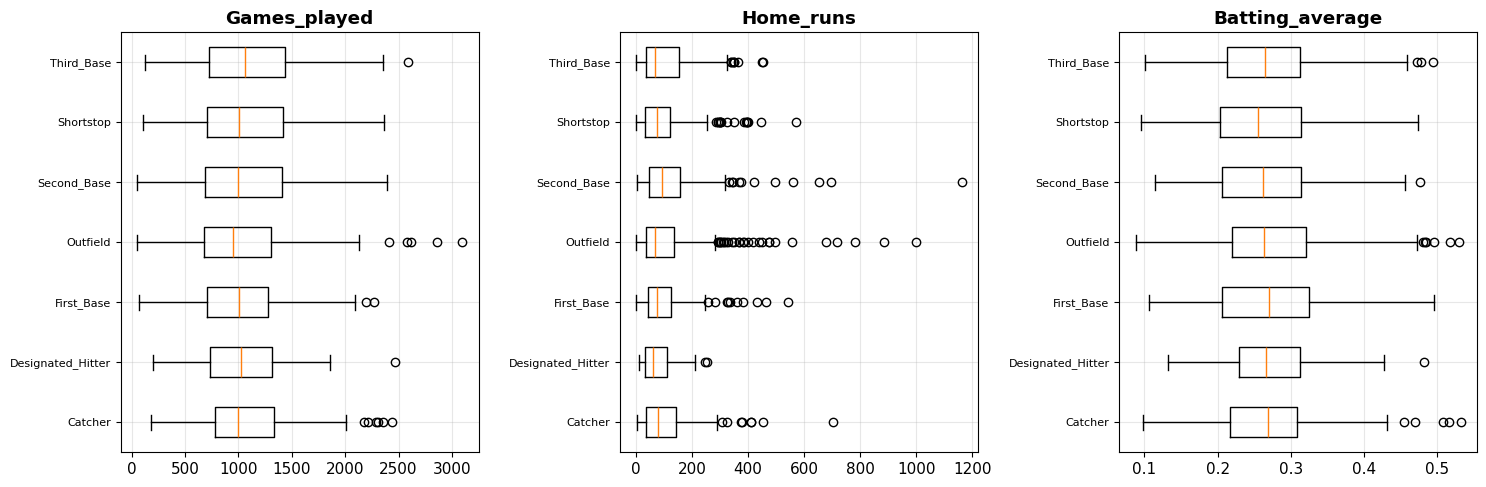

In [7]:
# Figure 4.6: Boxplots of numeric features conditioned on Position
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Games_played', 'Home_runs', 'Batting_average']):
    data_bp = [df.loc[df['Position']==pos, col].dropna().values
                for pos in sorted(df['Position'].unique())]
    bp = ax.boxplot(data_bp, labels=sorted(df['Position'].unique()), vert=False)
    ax.set_title(col, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
print("Figure 4.6: Feature distributions conditioned on Position.")
print("  Catchers show somewhat distinct patterns in some features.")

The boxplots reveal that **Position matters** -- particularly `Catcher`, which shows different distributions for some statistics. This is domain knowledge we might leverage: if we segment by position, we can find players who are unusual *for their position*, not just unusual overall. This is the local vs. global outlier distinction from Chapter 3 in action.

## 4.5 Cleaning the Data

Before fitting models, we perform two cleaning steps:
1. **Fill null values** -- most detectors cannot handle NaN
2. **Remove extreme outliers** -- to establish a cleaner baseline of "normal"

Removing strong outliers *before* modeling helps detectors form a more accurate model of normal data. After fitting, we add them back for scoring.

In [8]:
# Step 1: Fill nulls
print(f"Null values before: {df['Strikeouts'].isna().sum()}")
df['Strikeouts'] = df['Strikeouts'].fillna(df['Strikeouts'].median())
print(f"Null values after:  {df['Strikeouts'].isna().sum()}")
print(f"Filled with median: {df['Strikeouts'].median():.0f}")

Null values before: 20
Null values after:  0
Filled with median: 600


We fill the $20$ null values in `Strikeouts` with the column median. Using median rather than mean is preferable here because the median is robust to any extreme values that may be present in the non-null data.

In [9]:
# Step 2: Remove extreme values using IQR with k=3.5
# Listing 4.2: Removing extreme values
original_size = len(df)
limit_dict = {}
for col_name in df.columns:
    if df[col_name].dtype in ['int64', 'float64']:
        q1 = df[col_name].quantile(0.25)
        q3 = df[col_name].quantile(0.75)
        iqr = q3 - q1
        limit = q3 + (3.5 * iqr)
        limit_dict[col_name] = limit

cond = pd.Series([True] * len(df))
for key, limit in limit_dict.items():
    cond = cond & (df[key] <= limit)

clean_df = df[cond].copy()
removed_df = df[~cond].copy()

print(f"Listing 4.2: Removing extreme values (IQR, k=3.5)")
print(f"  Original rows:  {original_size}")
print(f"  Cleaned rows:   {len(clean_df)}")
print(f"  Removed:        {len(removed_df)} rows ({len(removed_df)/original_size*100:.1f}%)")
print(f"")
print(f"Features triggering removal:")
for key, limit in limit_dict.items():
    n_over = (df[key] > limit).sum()
    if n_over > 0:
        print(f"  {key}: {n_over} values > {limit:.1f}")

Listing 4.2: Removing extreme values (IQR, k=3.5)
  Original rows:  1340
  Cleaned rows:   1289
  Removed:        51 rows (3.8%)

Features triggering removal:
  Runs: 5 values > 1958.5
  Hits: 1 values > 3540.0
  Doubles: 10 values > 815.5
  Triples: 16 values > 158.6
  Home_runs: 15 values > 491.6
  RBIs: 8 values > 1891.5
  Walks: 10 values > 1480.5
  Strikeouts: 5 values > 2966.8


Using IQR with a coefficient of $3.5$ (more conservative than the standard $2.2$ from Chapter 2), we remove rows that have any feature value above $Q_3 + 3.5 \times \text{IQR}$. This is deliberately aggressive -- we are removing only the most extreme values to give our subsequent detectors a cleaner baseline.

The removed rows are not discarded permanently: after fitting models on the clean data, we add them back for scoring. They will almost certainly receive high outlier scores, which validates both the cleaning step and the detector.

## 4.6 Feature Selection

Feature selection is **considerably more important** for outlier detection than for prediction. Why? Predictive models (trees, neural nets) can learn which features are relevant from the target column and partially ignore irrelevant ones. Outlier detectors are *unsupervised* -- they treat **all features equally**. Every irrelevant feature adds noise, dilutes meaningful distances, and exacerbates the curse of dimensionality.

For each feature, ask: *If I found an extreme or unusual value in this column, would it be interesting?* If the answer is no, remove it.

In the baseball dataset, all $15$ numeric features are relevant career statistics, so we keep them all. In a more realistic business context, columns like internal IDs, timestamps used only for ordering, or administrative codes would typically be removed.

## 4.7 Feature Engineering

Feature engineering creates new features that expose anomalies invisible in the raw data. This is especially powerful for outlier detection because engineered features can convert **multivariate anomalies** (hard to detect) into **univariate anomalies** (easy to detect).

Common patterns:
- **Ratios** between related features (e.g., home runs per at-bat)
- **Differences** or **residuals** from expected relationships
- **Temporal features** extracted from dates (day of week, month, time since last event)
- **Rolling aggregates** (count in previous hour, average over last $N$ transactions)

Figure 4.7: Raw features vs engineered ratio.

Top 5 players by HR_per_AB:
      Games_played  At_bats  Home_runs  HR_per_AB
593            891     2525        373   0.147723
100            795     2413        327   0.135516
127           1187     2957        400   0.135272
1020           928     3399        449   0.132098
1096          1257     1726        209   0.121089


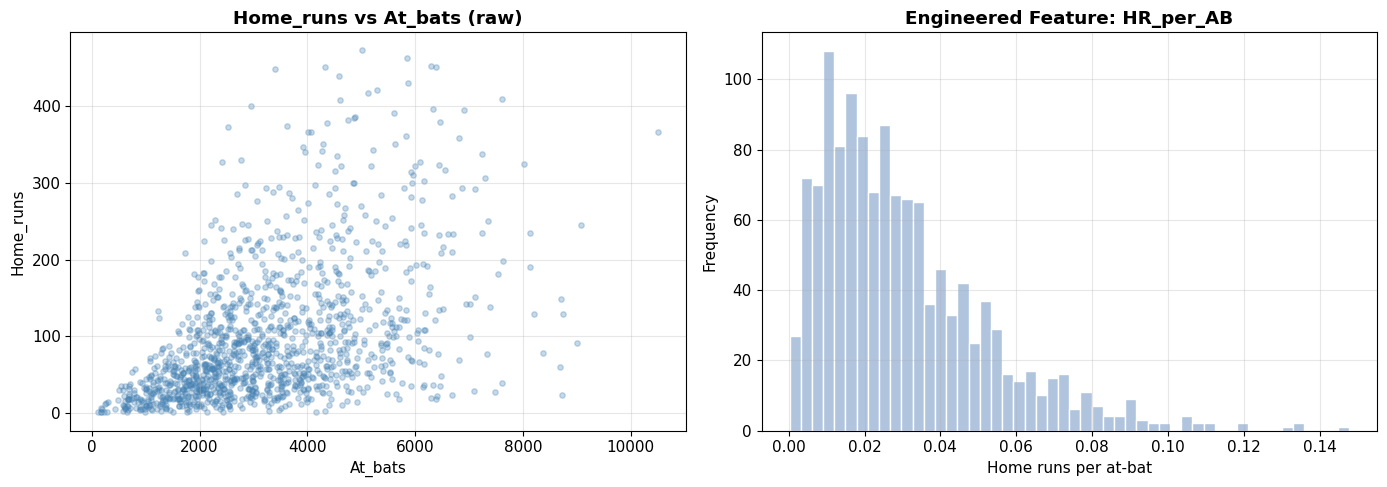

In [10]:
# Listing 4.3: Engineering features -- Home runs per at bat
df_eng = clean_df.copy()

# Ratio features
df_eng['HR_per_AB'] = df_eng['Home_runs'] / df_eng['At_bats'].clip(lower=1)
df_eng['Runs_per_game'] = df_eng['Runs'] / df_eng['Games_played'].clip(lower=1)
df_eng['Extra_base_hits'] = df_eng['Doubles'] + df_eng['Triples'] + df_eng['Home_runs']
df_eng['Walk_rate'] = df_eng['Walks'] / df_eng['At_bats'].clip(lower=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatterplot of original features
ax = axes[0]
ax.scatter(df_eng['At_bats'], df_eng['Home_runs'], alpha=0.3, s=15, c='steelblue')
ax.set_xlabel('At_bats')
ax.set_ylabel('Home_runs')
ax.set_title('Home_runs vs At_bats (raw)', fontweight='bold')

# Histogram of engineered ratio
ax = axes[1]
ax.hist(df_eng['HR_per_AB'], bins=50, color='lightsteelblue', edgecolor='white')
ax.set_xlabel('Home runs per at-bat')
ax.set_ylabel('Frequency')
ax.set_title('Engineered Feature: HR_per_AB', fontweight='bold')

plt.tight_layout()

# Show extreme values in the engineered feature
top_hr_rate = df_eng.nlargest(5, 'HR_per_AB')[['Games_played', 'At_bats', 'Home_runs', 'HR_per_AB']]
print("Figure 4.7: Raw features vs engineered ratio.")
print(f"")
print(f"Top 5 players by HR_per_AB:")
print(top_hr_rate.to_string())

This recreates the book's Figure 4.7. The left panel shows the raw relationship between at-bats and home runs -- correlated, with some spread, but no obvious individual outliers. The right panel shows the **engineered ratio** `HR_per_AB`, which reveals clear outliers: players with an unusually high rate of home runs per at-bat.

The ratio distills a multivariate pattern (the relationship between two features) into a single number that can be checked with a simple univariate test. This is a major advantage: univariate tests on engineered features are **faster**, **more reliable**, and **more interpretable** than multivariate tests on raw features.

The top-$5$ players by `HR_per_AB` would likely be flagged by any univariate test. Some may be genuinely exceptional power hitters; others may have very few at-bats (small sample sizes producing extreme rates). Both are interesting findings -- the former is a performance outlier, the latter is a data characteristic worth noting.

## 4.8 Encoding Categorical Values

Most outlier detectors require purely numeric data. Common encoding methods:

**One-hot encoding** (`pd.get_dummies()`): Creates a binary column for each unique value. Best when cardinality is low. Can increase dimensionality significantly.

**Ordinal encoding**: Replaces each value with an integer. Implies an ordering that may not exist, but avoids dimensionality explosion.

**Count encoding**: Replaces each value with its frequency count. Naturally captures rarity -- rare values get low encodings, which distance-based methods may interpret as unusual.

For the baseball data with only $7$ unique positions, one-hot encoding is appropriate.

In [11]:
# Encode and scale
df_model = df_eng.copy()

# One-hot encode Position
df_model = pd.get_dummies(df_model, columns=['Position'])
print(f"Shape after one-hot encoding: {df_model.shape}")
print(f"New columns: {[c for c in df_model.columns if c.startswith('Position_')]}")

Shape after one-hot encoding: (1289, 26)
New columns: ['Position_Catcher', 'Position_Designated_Hitter', 'Position_First_Base', 'Position_Outfield', 'Position_Second_Base', 'Position_Shortstop', 'Position_Third_Base']


One-hot encoding added $7$ binary columns (one per position), replacing the single `Position` column. The dataset now has $23$ numeric features -- all ready for scaling.

## 4.9 Scaling Numeric Values

Distance-, density-, and clustering-based detectors require all features to be on comparable scales. Without scaling, features on large scales (like `Games_played`, range $50$--$3{,}600$) would dominate distance calculations, making features on small scales (like `Batting_average`, range $0.1$--$0.4$) irrelevant.

The book recommends **Robust Scaling**, which uses median and IQR instead of mean and standard deviation:

$$x_{\text{scaled}} = \frac{x - \text{median}}{\text{IQR}}$$

This is preferred for outlier detection because the outliers we are trying to detect don't distort the scaling (unlike `StandardScaler`, where extreme values inflate $\sigma$).

Figure 4.8: Data before and after scaling.
  Before: Games_played range [50, 2861]
  After:  Games_played range [-1.52, 3.15]
  Before: Triples range [0, 158]
  After:  Triples range [-0.65, 4.45]


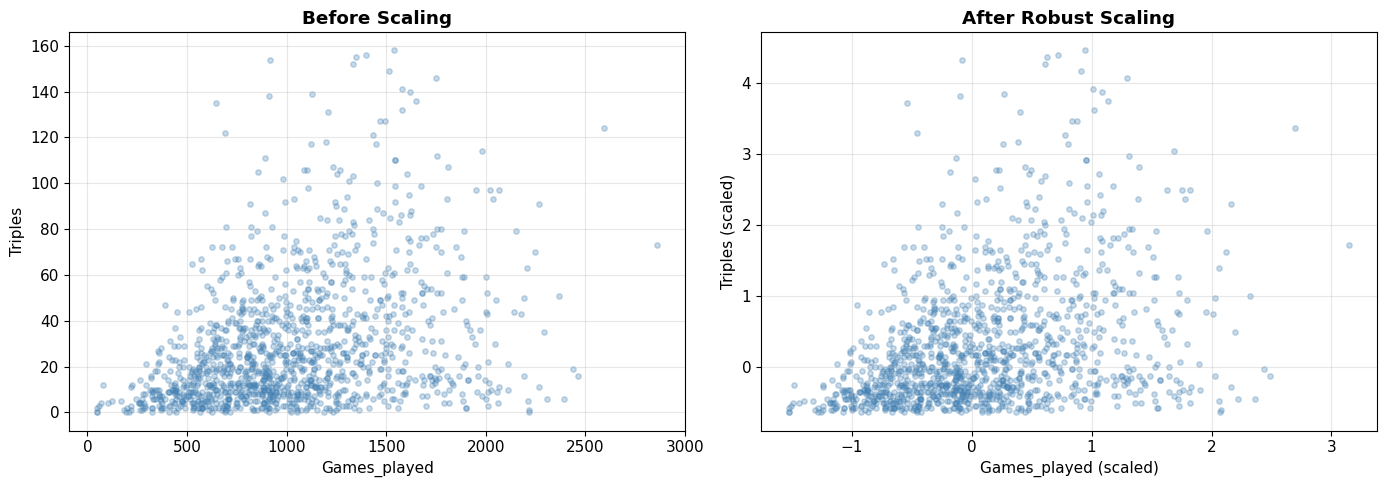

In [12]:
# Figure 4.8: Before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
ax = axes[0]
ax.scatter(df_model['Games_played'], df_model['Triples'], alpha=0.3, s=15, c='steelblue')
ax.set_xlabel('Games_played')
ax.set_ylabel('Triples')
ax.set_title('Before Scaling', fontweight='bold')

# Scale
scaler = RobustScaler()
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
df_scaled = pd.DataFrame(scaler.fit_transform(df_model[numeric_cols]), columns=numeric_cols, index=df_model.index)

# After scaling
ax = axes[1]
ax.scatter(df_scaled['Games_played'], df_scaled['Triples'], alpha=0.3, s=15, c='steelblue')
ax.set_xlabel('Games_played (scaled)')
ax.set_ylabel('Triples (scaled)')
ax.set_title('After Robust Scaling', fontweight='bold')

plt.tight_layout()
print("Figure 4.8: Data before and after scaling.")
print(f"  Before: Games_played range [{df_model['Games_played'].min()}, {df_model['Games_played'].max()}]")
print(f"  After:  Games_played range [{df_scaled['Games_played'].min():.2f}, {df_scaled['Games_played'].max():.2f}]")
print(f"  Before: Triples range [{df_model['Triples'].min()}, {df_model['Triples'].max()}]")
print(f"  After:  Triples range [{df_scaled['Triples'].min():.2f}, {df_scaled['Triples'].max():.2f}]")

The distributions are identical before and after scaling -- only the axis scales change. After robust scaling, both features have comparable ranges centered near zero, with IQR approximately $1$. Now Euclidean distance calculations will weight both features equally, as intended.

## 4.10 Fitting Models and Generating Predictions

We now apply multiple detectors to the scaled data and compare their results. As the book emphasizes: **always try several detectors**. If we run only one or two, we have no way to know if significant outliers remain undetected. Running many detectors and manually assessing results is the best path to comprehensive detection.

### DBSCAN

DBSCAN (eps=2.0): 916 inliers, 373 outliers
DBSCAN sweep (23 eps values):
  Score range: [3, 21]
  Points never flagged: 0
  Points always flagged: 0


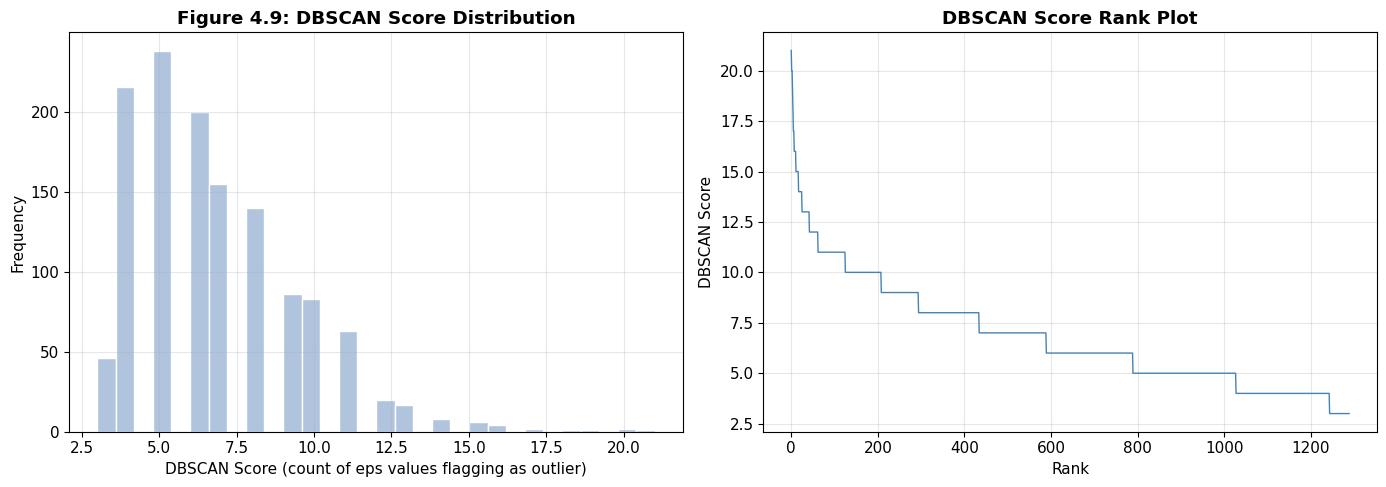

In [13]:
# Listing 4.4-4.5: DBSCAN with varied eps
dbscan_scores = np.zeros(len(df_scaled))

eps_values = np.arange(0.5, 5.0, 0.2)
for eps in eps_values:
    labels = DBSCAN(eps=eps).fit_predict(df_scaled)
    dbscan_scores += np.where(labels < 0, 1, 0)

# Also get a single DBSCAN run for binary labels
labels_single = DBSCAN(eps=2.0).fit_predict(df_scaled)
n_inliers = (labels_single >= 0).sum()
n_outliers = (labels_single < 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(dbscan_scores, bins=30, color='lightsteelblue', edgecolor='white')
ax.set_xlabel('DBSCAN Score (count of eps values flagging as outlier)')
ax.set_ylabel('Frequency')
ax.set_title('Figure 4.9: DBSCAN Score Distribution', fontweight='bold')

ax = axes[1]
ax.plot(range(len(dbscan_scores)), sorted(dbscan_scores, reverse=True), 'steelblue', linewidth=1)
ax.set_xlabel('Rank')
ax.set_ylabel('DBSCAN Score')
ax.set_title('DBSCAN Score Rank Plot', fontweight='bold')

plt.tight_layout()

print(f"DBSCAN (eps=2.0): {n_inliers} inliers, {n_outliers} outliers")
print(f"DBSCAN sweep ({len(eps_values)} eps values):")
print(f"  Score range: [{dbscan_scores.min():.0f}, {dbscan_scores.max():.0f}]")
print(f"  Points never flagged: {(dbscan_scores == 0).sum()}")
print(f"  Points always flagged: {(dbscan_scores == len(eps_values)).sum()}")

This implements the book's Listings 4.4--4.5. Instead of relying on a single `eps` value (which requires careful tuning), we sweep across a range and count how many values flag each point as an outlier. Points that are flagged across *many* `eps` values are robustly identified as outliers regardless of the parameter choice.

The score distribution (left) and rank plot (right) show the typical pattern: most points are never or rarely flagged, with a long tail of increasingly outlierish points. The rank plot helps identify natural breakpoints for thresholding.

### KNN

KNN (k=4) score distribution:
  Min: 0.6722
  Median: 1.2277
  95th pctl: 2.1188
  Max: 3.5830


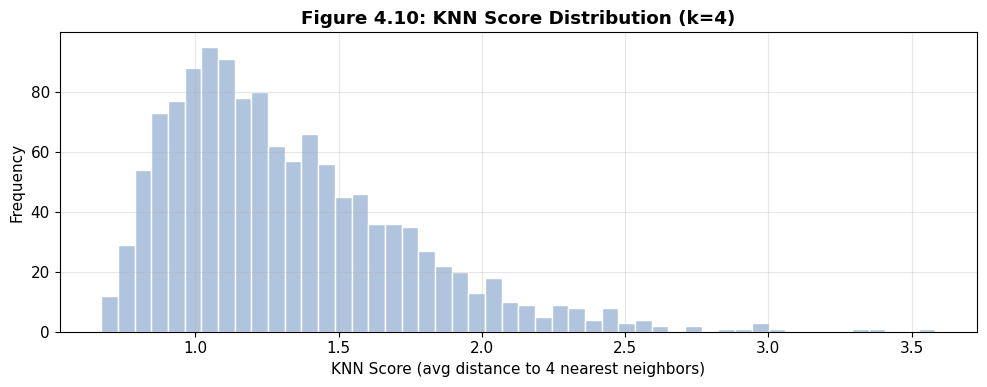

In [14]:
# Listing 4.6: KNN on baseball data
tree = BallTree(df_scaled.values)
dist, _ = tree.query(df_scaled.values, k=4)
knn_scores = np.array([x.mean() for x in dist])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(knn_scores, bins=50, color='lightsteelblue', edgecolor='white')
ax.set_xlabel('KNN Score (avg distance to 4 nearest neighbors)')
ax.set_ylabel('Frequency')
ax.set_title('Figure 4.10: KNN Score Distribution (k=4)', fontweight='bold')

plt.tight_layout()

print(f"KNN (k=4) score distribution:")
print(f"  Min: {knn_scores.min():.4f}")
print(f"  Median: {np.median(knn_scores):.4f}")
print(f"  95th pctl: {np.percentile(knn_scores, 95):.4f}")
print(f"  Max: {knn_scores.max():.4f}")

The KNN score distribution mirrors Figure 4.10 from the book. The bulk of scores cluster at low values (most players have nearby neighbors), with a right tail of isolated players. The distribution appears reasonable -- no extreme spikes or gaps that would suggest a problem with the method or parameters.

Figure 4.11: KNN outliers (top 3% = 39 points) shown as red stars.


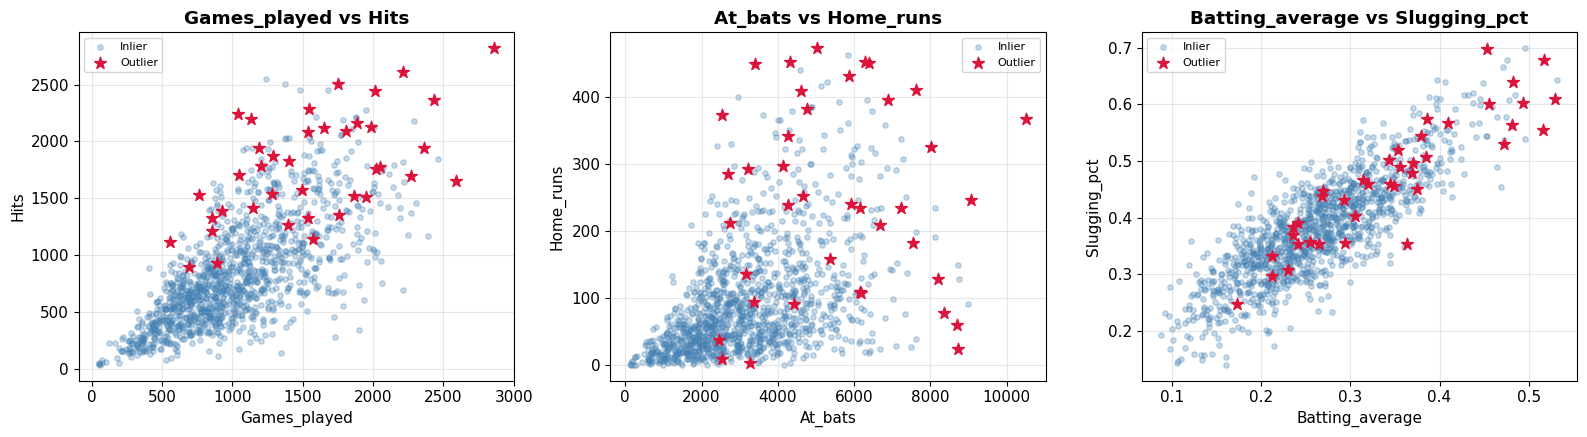

In [15]:
# Figure 4.11: Scatterplots showing KNN-flagged outliers
knn_threshold = np.percentile(knn_scores, 97)  # top 3%
knn_outlier_mask = knn_scores > knn_threshold

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs = [('Games_played', 'Hits'), ('At_bats', 'Home_runs'), ('Batting_average', 'Slugging_pct')]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_model.loc[df_scaled.index[~knn_outlier_mask], x],
               df_model.loc[df_scaled.index[~knn_outlier_mask], y],
               alpha=0.3, s=15, c='steelblue', label='Inlier')
    ax.scatter(df_model.loc[df_scaled.index[knn_outlier_mask], x],
               df_model.loc[df_scaled.index[knn_outlier_mask], y],
               c='crimson', s=80, marker='*', zorder=5, label='Outlier')
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()

n_knn_out = knn_outlier_mask.sum()
print(f"Figure 4.11: KNN outliers (top 3% = {n_knn_out} points) shown as red stars.")

As the book observes, the KNN-flagged outliers are predominantly **extreme values** rather than unusual combinations -- they sit at the edges of the scatterplots in one or both dimensions. This is expected: with $23$ features after encoding, the distance calculations are dominated by features where a player has an unusually large or small value.

Flagging unusual *combinations* would require either (a) more emphasis on engineered features (like `HR_per_AB`) or (b) local outlier methods (like LOF) that compare each point to its specific neighborhood rather than the global distribution.

## 4.11 Evaluating the Models

Evaluation is the hardest part of outlier detection. Without labels, we cannot compute precision, recall, or F1. The book identifies several practical evaluation strategies:

1. **Manual inspection** of top-scored records: Are they genuinely interesting?
2. **Spot-checking** of low-scored records: Are we missing anything obvious?
3. **Comparing multiple detectors**: Agreement adds confidence; disagreement reveals different perspectives
4. **Testing with synthetic outliers**: Create a pseudo-ground truth (covered in Chapter 11)

### The "Myth of Average"

A key insight: with enough features, **no record is completely average**. Every player will be unusual in *some* dimension. This means almost any record can receive a non-zero outlier score if we look hard enough. The practical implication: we should focus on records that are unusual in *meaningful* ways, not just *any* way.

### Comparing Detectors

Figure 4.12: Detector score correlations.
  KNN vs KDE:    r = 0.856
  KNN vs Radius: r = 0.737
  Radius vs KDE: r = 0.957


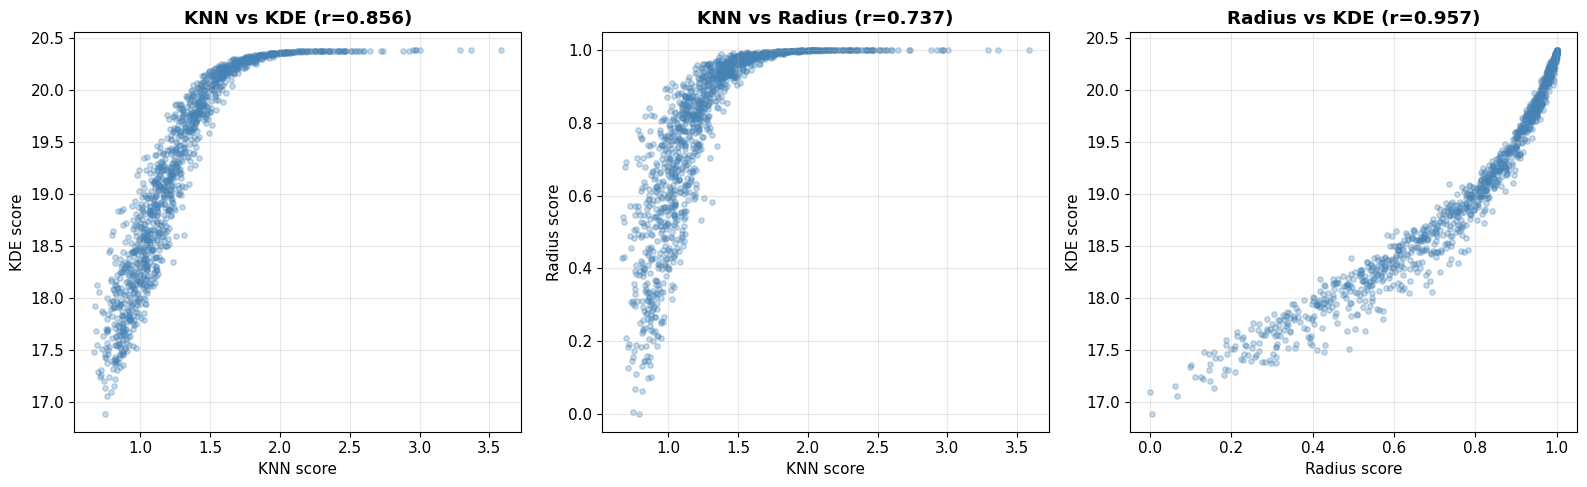

In [16]:
# Figure 4.12: Comparing detector scores
# KDE scores
kde = KernelDensity(kernel='gaussian', bandwidth=0.8).fit(df_scaled.values)
kde_scores = -kde.score_samples(df_scaled.values)  # negate: low density = high score

# Radius scores
tree_r = BallTree(df_scaled.values)
counts_r = tree_r.query_radius(df_scaled.values, 2.5, count_only=True)
max_c, min_c = counts_r.max(), counts_r.min()
radius_scores = np.array([(max_c - x) / (max_c - min_c) for x in counts_r])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [('KNN', knn_scores, 'KDE', kde_scores),
         ('KNN', knn_scores, 'Radius', radius_scores),
         ('Radius', radius_scores, 'KDE', kde_scores)]

for ax, (n1, s1, n2, s2) in zip(axes, pairs):
    ax.scatter(s1, s2, alpha=0.3, s=15, c='steelblue')
    r = np.corrcoef(s1, s2)[0, 1]
    ax.set_xlabel(f'{n1} score')
    ax.set_ylabel(f'{n2} score')
    ax.set_title(f'{n1} vs {n2} (r={r:.3f})', fontweight='bold')

plt.tight_layout()

print("Figure 4.12: Detector score correlations.")
print(f"  KNN vs KDE:    r = {np.corrcoef(knn_scores, kde_scores)[0,1]:.3f}")
print(f"  KNN vs Radius: r = {np.corrcoef(knn_scores, radius_scores)[0,1]:.3f}")
print(f"  Radius vs KDE: r = {np.corrcoef(radius_scores, kde_scores)[0,1]:.3f}")

This recreates the book's Figure 4.12. The detector scores show **positive but imperfect correlations** -- they agree on the most extreme outliers but disagree on moderate ones. This is exactly what we want to see:

**High agreement on extremes** means the most flagged records are robustly unusual from multiple perspectives -- these are our highest-confidence outliers.

**Disagreement on moderates** means each detector brings a unique perspective. KNN emphasizes distance to neighbors, KDE emphasizes local density, and Radius emphasizes the count of nearby points. Their differences are complementary, not contradictory.

In an **ensemble** (Chapter 12), we would combine these scores -- averaging out individual detector biases and producing a more robust final ranking. Records that score high across *all* detectors are the strongest candidates for investigation.

## 4.12 Setting Up Ongoing Outlier Detection

For one-off projects, we simply collect the most interesting outliers and report them. For ongoing systems, several additional considerations arise:

### Ensembles of Detectors
No single detector identifies all anomalies. Using multiple detectors with combined scores provides broader coverage and more robust rankings. We cover this in depth in Chapter 12.

### Collective Outliers
Sometimes no single row is unusual, but a *pattern* across rows is anomalous: an unusual number of transactions in a period, gaps in a sequence, or correlated timing across records. Detecting these requires **reformatting the data** -- for example, aggregating by time period and running outlier detection on the aggregates. We cover this in Chapters 15--17.

### Model Refitting
The question "unusual compared to *what*?" is central. Models trained on historical data may not reflect the current normal. Options include:
- **Fixed reference set**: compare against a known-good historical period
- **Rolling window**: always compare against the most recent $N$ days/weeks
- **Multiple references**: compare against several historical periods simultaneously

Each has tradeoffs. Fixed references are stable but may become stale. Rolling windows adapt to change but may normalize genuine anomalies if they persist. Multiple references provide the most context but add complexity.

### The Feedback Loop
Over time, as flagged outliers are assessed, we accumulate **labeled data**. This enables:
1. Better evaluation of detectors (finally, we have ground truth)
2. Tuning thresholds based on observed false positive/negative rates
3. Potentially training **classifiers** on the accumulated labels for more targeted detection
4. Discovery of new types of outliers, which may be encoded as new **rules**

## 4.13 Chapter Summary

This chapter covered the end-to-end outlier detection process:

**Before modeling:**
- Determine the type of outliers (statistical vs. specific, known vs. unknown)
- Choose the approach (rules, classifiers, detectors, or a combination)
- Collect representative data -- not just normal rows, but data that follows the true distributions
- Perform EDA to understand the data structure and spot obvious issues
- Clean the data: fill nulls and remove extreme outliers to create a clean training set

**Feature preparation:**
- Feature selection is more critical than in prediction because detectors treat all features equally
- Feature engineering converts multivariate anomalies into univariate ones (ratios, differences, aggregates)
- Encode categorical features (one-hot, ordinal, or count encoding)
- Scale numeric features with `RobustScaler` (median/IQR-based, robust to outliers)

**Modeling and evaluation:**
- Always try multiple detectors with varied parameters
- Sweep hyperparameters (e.g., DBSCAN `eps`) and aggregate results for robustness
- Compare detector scores: agreement = confidence; disagreement = complementary perspectives
- Manual inspection remains the gold standard for evaluation
- Spot-check both high-scored *and* low-scored records

**Production systems:**
- Use ensembles of detectors for broader coverage
- Reformat data to detect collective outliers and time-series anomalies
- Refit models periodically as data evolves
- Log and assess flagged outliers to build labeled data over time
- Use the feedback loop to continuously improve the system

In the next chapter, we examine **Isolation Forest** -- one of the most popular and practical outlier detectors, notable for its speed, scalability, and minimal parameter sensitivity.

## Appendix: OpenML Baseball Dataset (Run on Google Colab)

(1340, 16)
   Number_seasons  Games_played  At_bats  Runs  Hits  Doubles  Triples  \
0              23          3298    12364  2174  3771      624       98   
1              13          1165     4019   378  1022      163       19   
2              13          1424     5557   844  1588      249       48   
3              14          1281     4019   591  1082      188       49   
4              17          1959     6606   823  1832      295       35   

   Home_runs  RBIs  Walks  Strikeouts  Batting_average  On_base_pct  \
0        755  2297   1402      1383.0            0.305        0.377   
1         57   366    208       499.0            0.254        0.294   
2          9   394    453       223.0            0.286        0.343   
3         37   303    414       447.0            0.269        0.340   
4        336  1122    594      1059.0            0.277        0.339   

   Slugging_pct  Fielding_ave     Position  
0         0.555         0.980     Outfield  
1         0.347         0.9

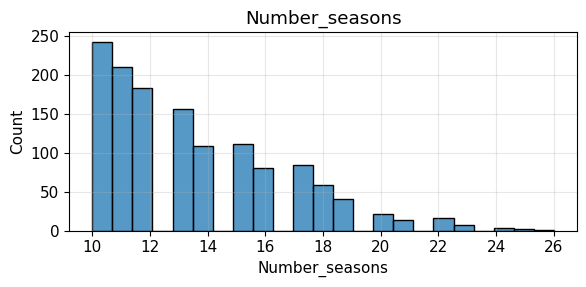

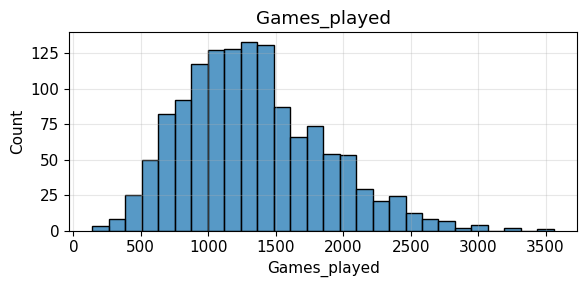

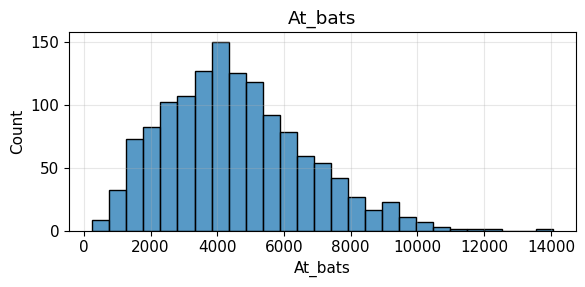

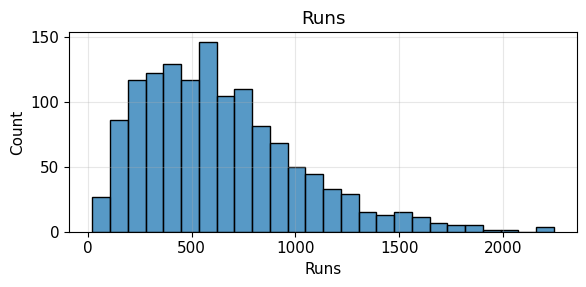

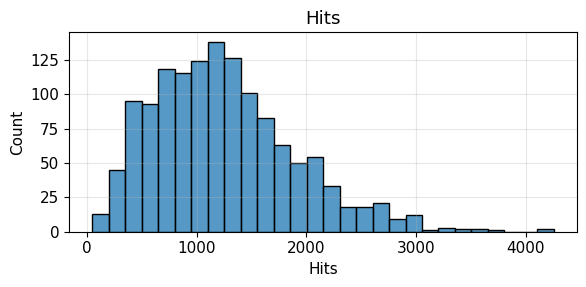

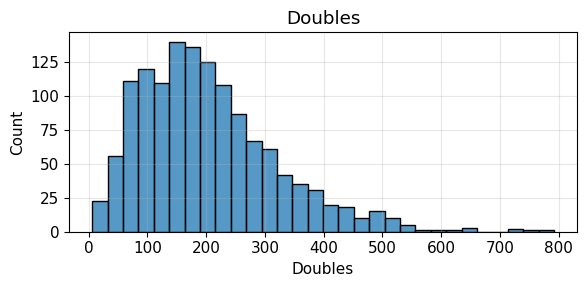

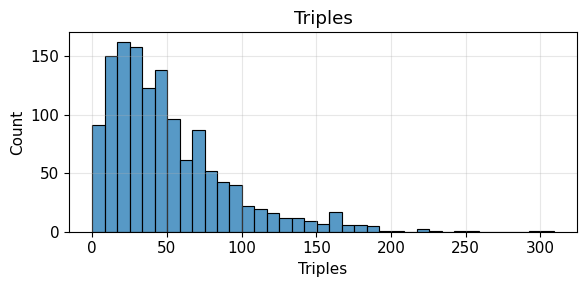

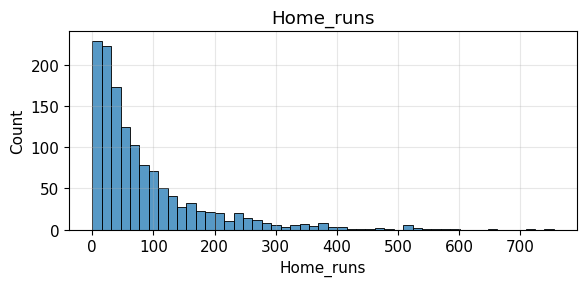

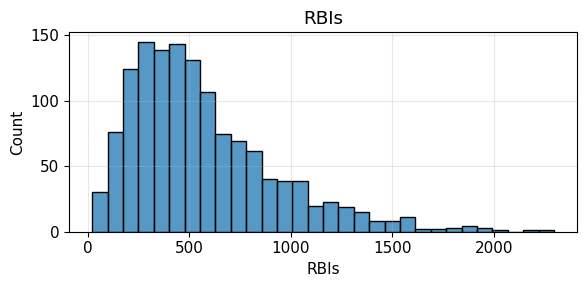

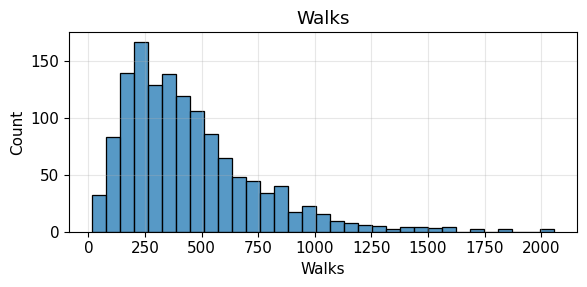

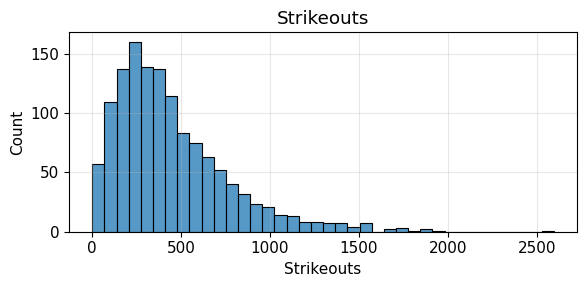

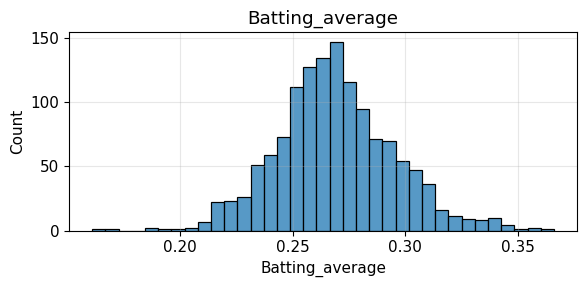

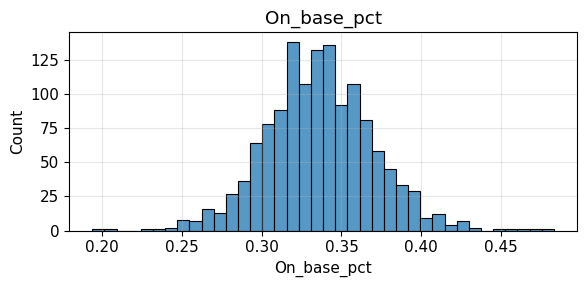

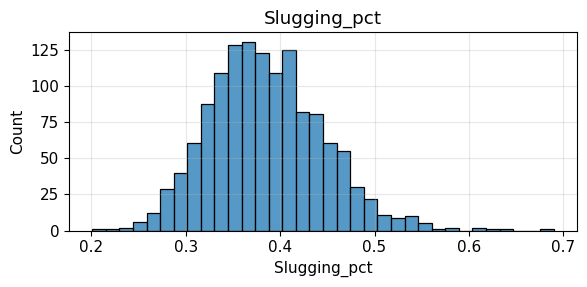

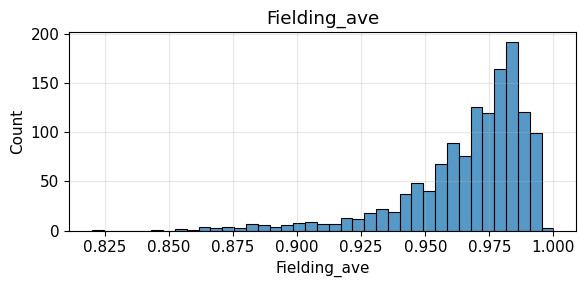

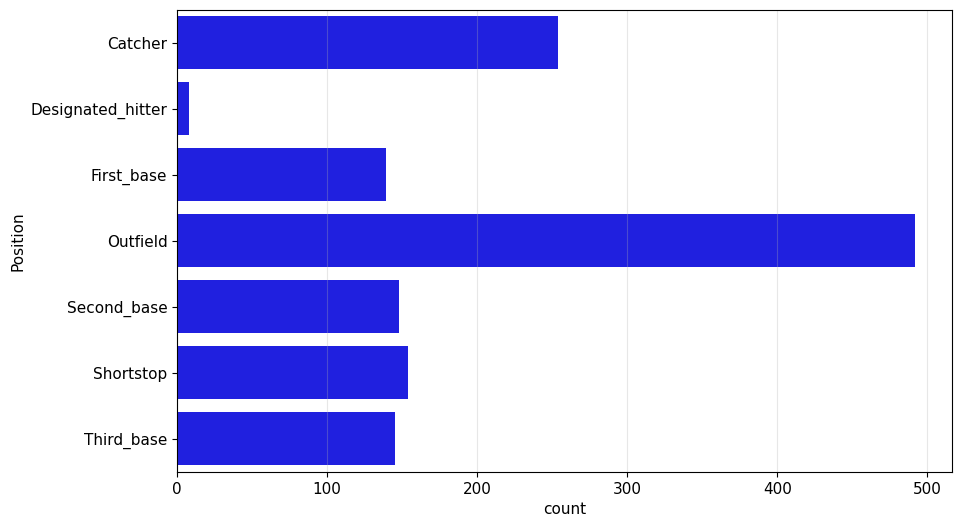

In [17]:
# Run on Google Colab -- Listing 4.1: Loading and examining the baseball dataset
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns

data = fetch_openml('baseball', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
print(df.shape)
print(df.head())
print(df.dtypes)

# Histograms of numeric features
for col_name in df.columns:
    if df[col_name].dtype in ['int64', 'float64']:
        fig, ax = plt.subplots(figsize=(6, 3))
        sns.histplot(data=df[col_name], ax=ax)
        ax.set_title(col_name)
        plt.tight_layout()
        plt.show()

# Position distribution
sns.countplot(data=df, y='Position', orient='h', color='blue')
plt.show()

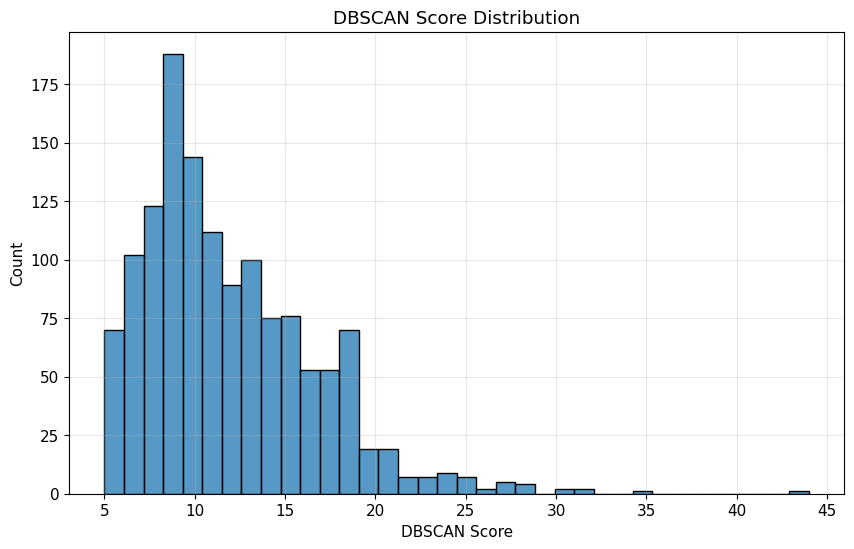

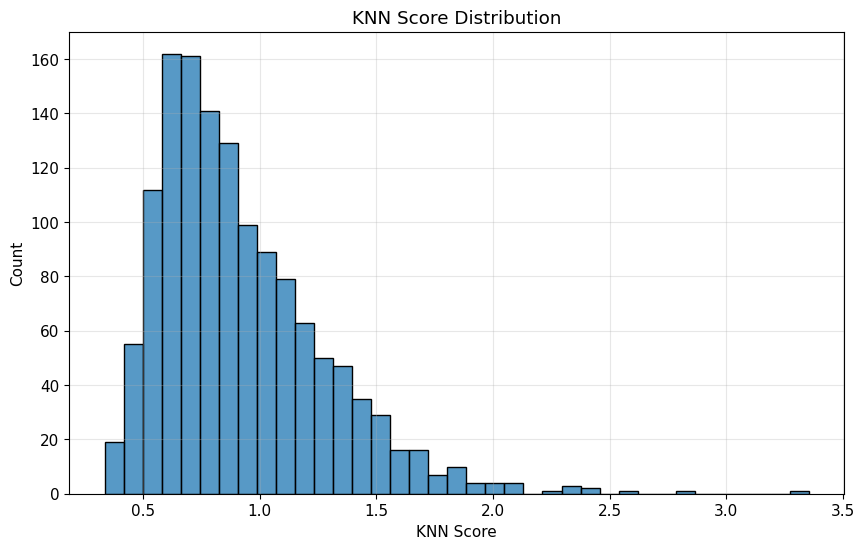

In [18]:
# Run on Google Colab -- Listings 4.4-4.6: Full pipeline on baseball data
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess
data = fetch_openml('baseball', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Strikeouts'] = df['Strikeouts'].fillna(df['Strikeouts'].median())
df = pd.get_dummies(df)
scaler = RobustScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# DBSCAN sweep
df_scaled['DBSCAN Score'] = 0
for eps in np.arange(0.1, 5.0, 0.1):
    df_scaled['DBSCAN Score'] += np.where(DBSCAN(eps=eps).fit_predict(df_scaled.drop(columns=['DBSCAN Score'])) < 0, 1, 0)
sns.histplot(df_scaled['DBSCAN Score'])
plt.title('DBSCAN Score Distribution')
plt.show()

# KNN
tree = BallTree(df_scaled.drop(columns=['DBSCAN Score']))
dist, ind = tree.query(df_scaled.drop(columns=['DBSCAN Score']), k=4)
df_scaled['KNN Score'] = [x.mean() for x in dist]
sns.histplot(df_scaled['KNN Score'])
plt.title('KNN Score Distribution')
plt.show()